# RAG using LangGraph


In [ ]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain.tools import tool
from typing import TypedDict,List,Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import BaseMessage,add_messages
from langchain.messages import HumanMessage,SystemMessage
import os

In [71]:
load_dotenv()

True

In [72]:
os.environ["LANGSMITH_PROJECT"]="RAG_USING_LANGGRAPH_and_LANGCHAIN"

In [2]:
loader=PyPDFLoader("data\\Hands-On-Machine-Learning-with-Scikit-Learn-Keras-and-TensorFlow.pdf")
docs=loader.load()

In [9]:
print(len(docs))

1351


In [3]:
splitter=RecursiveCharacterTextSplitter(chunk_overlap=100,chunk_size=800)

In [4]:
chunks=splitter.split_documents(docs)

In [6]:
embeddings=HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

c:\Users\ACER\OneDrive\Desktop\ARTIFICIAL INTELLIGENCE\RAG using LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2478.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
vector_store=Chroma.from_documents(
    documents=chunks,
    embedding=embeddings
)

In [10]:
vector_store

In [8]:
retriever=vector_store.as_retriever(search_type="similarity",search_kwargs={'k':5})

In [29]:
@tool
def rag_tool(query):
    """
    use this tool when user ask related to some factual / conceptual data related to the uploaded or provided
    pdf file and if teh question or user query out of this pdf file then say simply I Don't know .
    """
    result=retriever.invoke(query)
    
    context= [docs.page_content for docs in result]
    metadata= [docs.metadata for docs in result]
    
    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [25]:
tools=[rag_tool]

In [27]:
retriever.invoke("what is Decision Tree?")[1].page_content

'Figure 6-2. \nDecision tree decision boundaries\nTIP\nThe tree structure, including all the information shown in \nFigure 6-1\n, is available via the\nclassifier’s \ntree_\n attribute. Type \nhelp(tree_clf.tree_)\n for details, and see the \nthis chapter’s\nnotebook\n for an example.\nMODEL INTERPRETATION: WHITE BOX VERSUS BLACK\nBOX\nDecision trees are intuitive, and their decisions are easy to interpret. Such\nmodels are often called \nwhite box models\n. \nIn contrast, as you will see,\nrandom forests and neural networks are generally considered \nblack box\nmodels\n. They make great predictions, and you can easily check the\ncalculations that they performed to make these predictions; nevertheless,\nit is usually hard to explain in simple terms why the predictions were'

In [ ]:
len(retriever.invoke("what is Decision Tree?"))  #because we defined kwargs={'k':5}

5

In [16]:
llm=ChatGroq(
    model="llama-3.1-8b-instant"
)

In [26]:
llm_with_tool=llm.bind_tools(tools)


In [43]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [38]:
tool_node=ToolNode(tools)

In [47]:
def chat_node(state:ChatState):
    message=state["messages"]
    response=llm_with_tool.invoke(message)
    return {"messages":[response]}

In [55]:
graph=StateGraph(ChatState)

graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)


graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")


workflow=graph.compile()


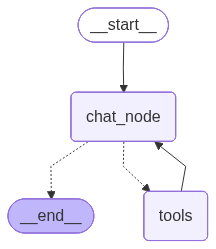

In [56]:
workflow

In [65]:
initial_state={"messages":[HumanMessage(content="""use the pdf information,A school wants to build a simple machine learning model to predict whether a student will pass or fail based on features like study hours, attendance, previous marks, and class participation. Explain how you would approach this problem: identify the type of problem, briefly describe how you would preprocess the data (especially categorical values and scaling), choose a suitable model, and mention how you would evaluate its performance.""")]}

In [66]:
response=workflow.invoke(initial_state)

In [68]:
response

{'messages': [HumanMessage(content='use the pdf information,A school wants to build a simple machine learning model to predict whether a student will pass or fail based on features like study hours, attendance, previous marks, and class participation. Explain how you would approach this problem: identify the type of problem, briefly describe how you would preprocess the data (especially categorical values and scaling), choose a suitable model, and mention how you would evaluate its performance.', additional_kwargs={}, response_metadata={}, id='64df9b4c-8f43-4d88-8ee9-3bc1aecbe699'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'c5wvxyfxx', 'function': {'arguments': '{"query":"What type of problem is this?"}', 'name': 'rag_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 231, 'prompt_tokens': 383, 'total_tokens': 614, 'completion_time': 0.287357989, 'completion_tokens_details': None, 'prompt_time': 0.023570067, 'prompt_tokens_det

In [69]:
print(response["messages"][-1].content)

This is a binary classification problem, where the goal is to predict whether a student will pass or fail based on various features such as study hours, attendance, previous marks, and class participation.

To approach this problem, I would follow these steps:

1. **Data Preprocessing**:
   - Handle missing values: Impute missing values using mean, median, or mode depending on the feature type.
   - Scale the data: Use standardization or normalization to ensure that all features are on the same scale.
   - Convert categorical values: One-hot encode or label encode categorical variables to convert them into numerical variables.
   - Split the data: Split the data into training (~80%) and testing sets (~20%).

2. **Choose a Suitable Model**:
   - Decision Trees: Decision Trees are a good choice for this problem as they can handle both categorical and numerical features. They are also easy to interpret and can handle non-linear relationships.
   - Random Forest: Random Forest is an ensemb